# Modeling, Calibration, and Responsible AI Audit

This notebook is the submission-facing analysis notebook. It runs the training pipeline, then summarizes the generated calibration, threshold, SHAP, and bias-audit artifacts for review.


In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
for candidate in [repo_root, repo_root.parent, repo_root / '..']:
    candidate = candidate.resolve()
    if (candidate / 'src' / 'train.py').exists():
        repo_root = candidate
        break

sys.path.insert(0, str(repo_root))
from src.train import main

main()


C:\Users\obili\AppData\Local\Temp\ipykernel_10112\4157713362.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
c:\Users\obili\OneDrive\Desktop\gpp\Hospital_readmission_riskpredictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- STARTING ML PIPELINE EXECUTION ---

[Step 1] Loading and cleaning dataset...
Original shape: (101766, 50)
Target distribution (binarized):
target
0    0.888401
1    0.111599
Name: proportion, dtype: float64
Shape after removing data leakage rows (expired/hospice): (99343, 51)
Removed 2423 rows due to leakage.

[Step 2] Splitting dataset...
Train set shape: (79474, 47), Test set shape: (19869, 47)
Train readmission rate: 0.1139, Test readmission rate: 0.1139

[Step 3] Training baseline Logistic Regression...
Fitting baseline pipeline...
Baseline Logistic Regression ROC-AUC: 0.6686
Baseline Logistic Regression PR-AUC: 0.2212

[Step 4] Training primary XGBoost classifier...
XGBoost scale_pos_weight for imbalance: 7.7807
Running RandomizedSearchCV...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best hyperparameters found:
 - classifier__subsample: 0.9
 - classifier__n_estimators: 200
 - classifier__max_depth: 4
 - classifier__learning_rate: 0.05
 - classifier__colsample_

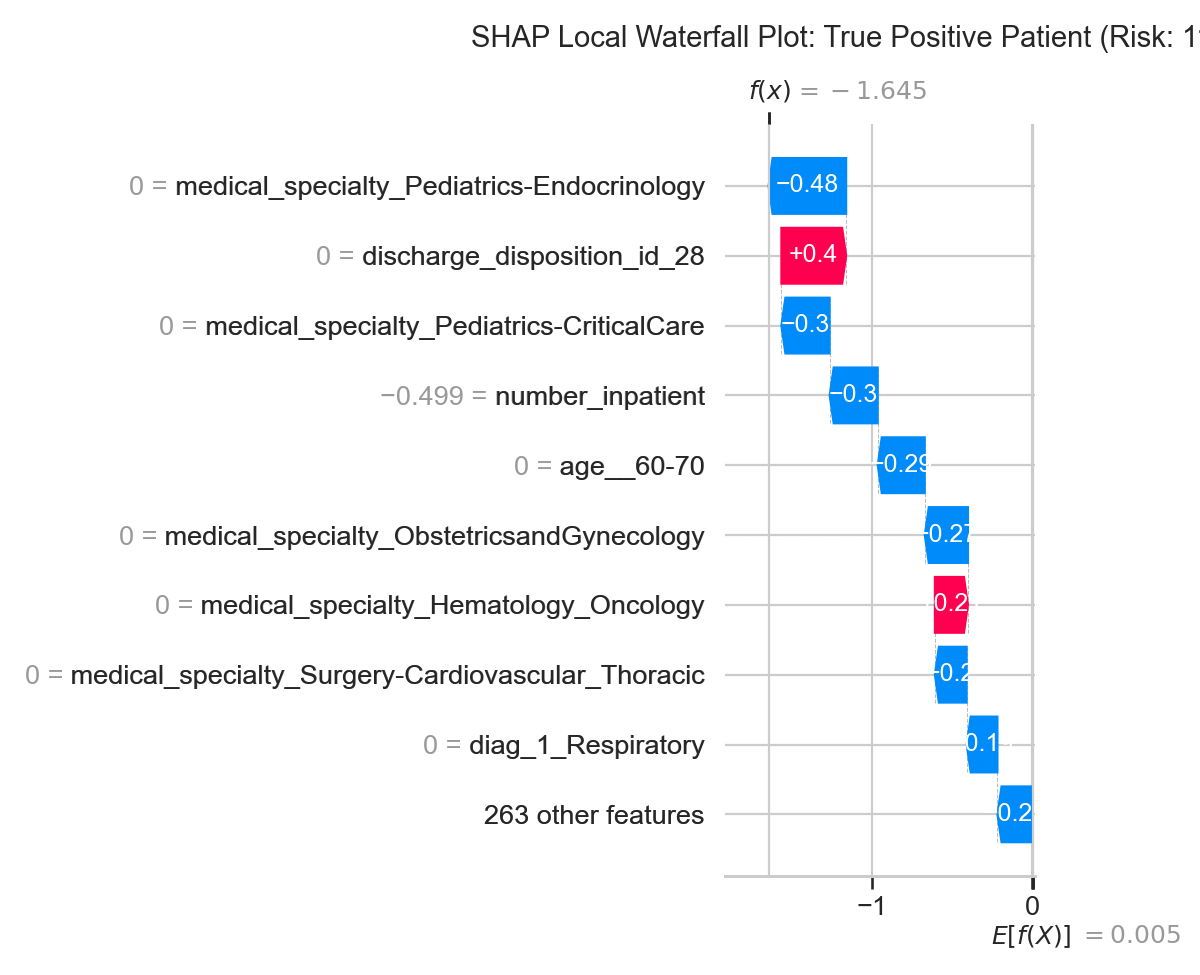

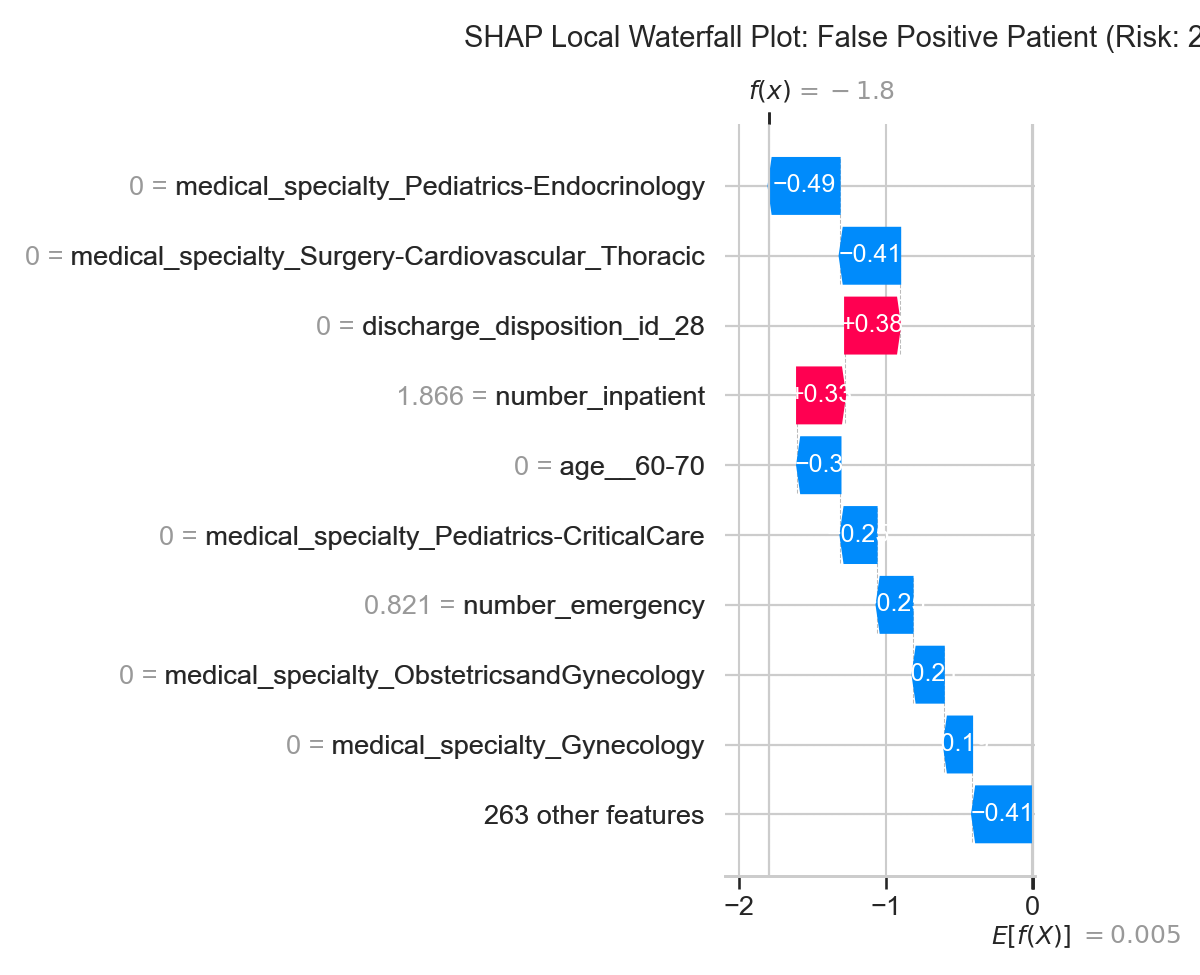

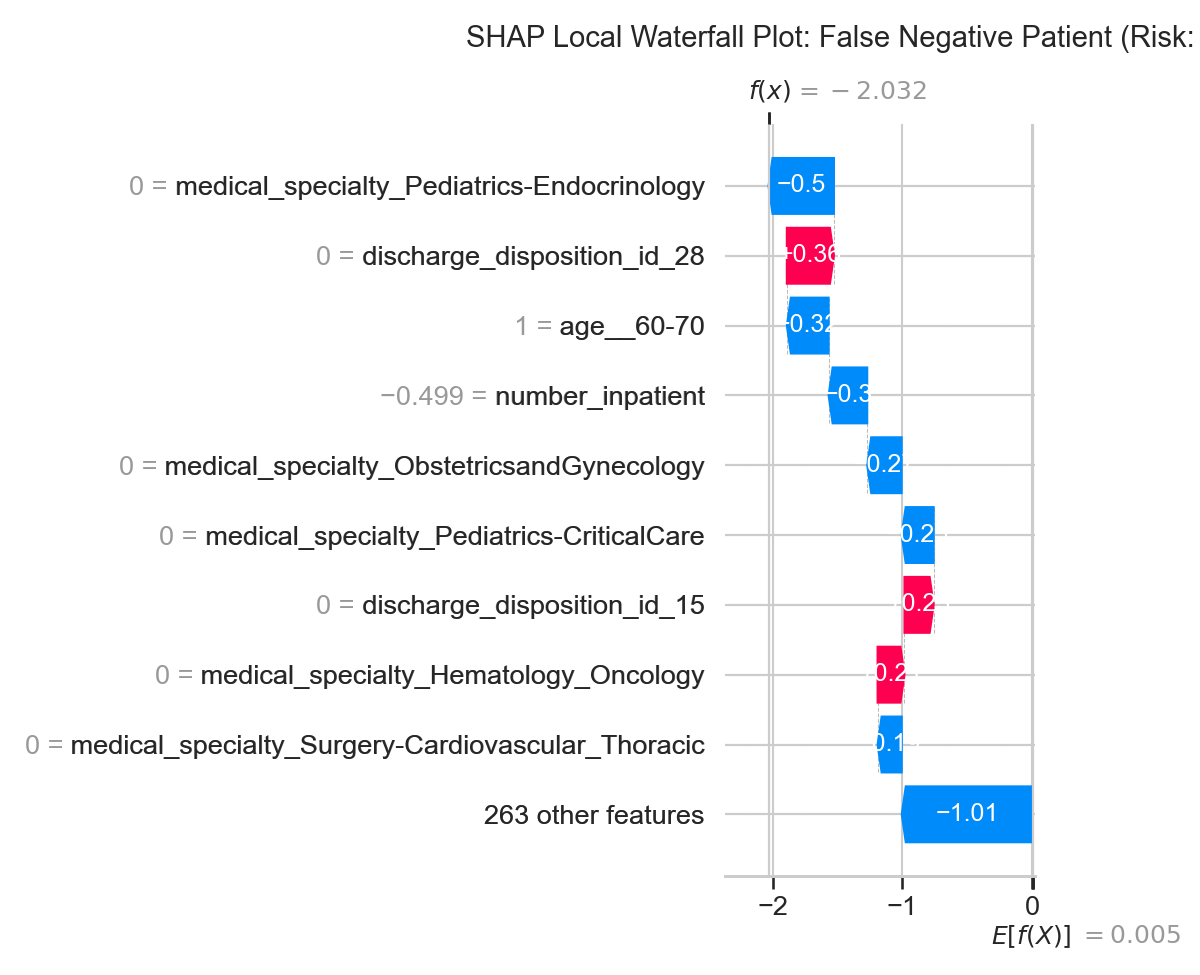

In [4]:
display(Image(filename=str(outputs_dir / 'shap_force_tp.png')))
display(Image(filename=str(outputs_dir / 'shap_force_fp.png')))
display(Image(filename=str(outputs_dir / 'shap_force_fn.png')))


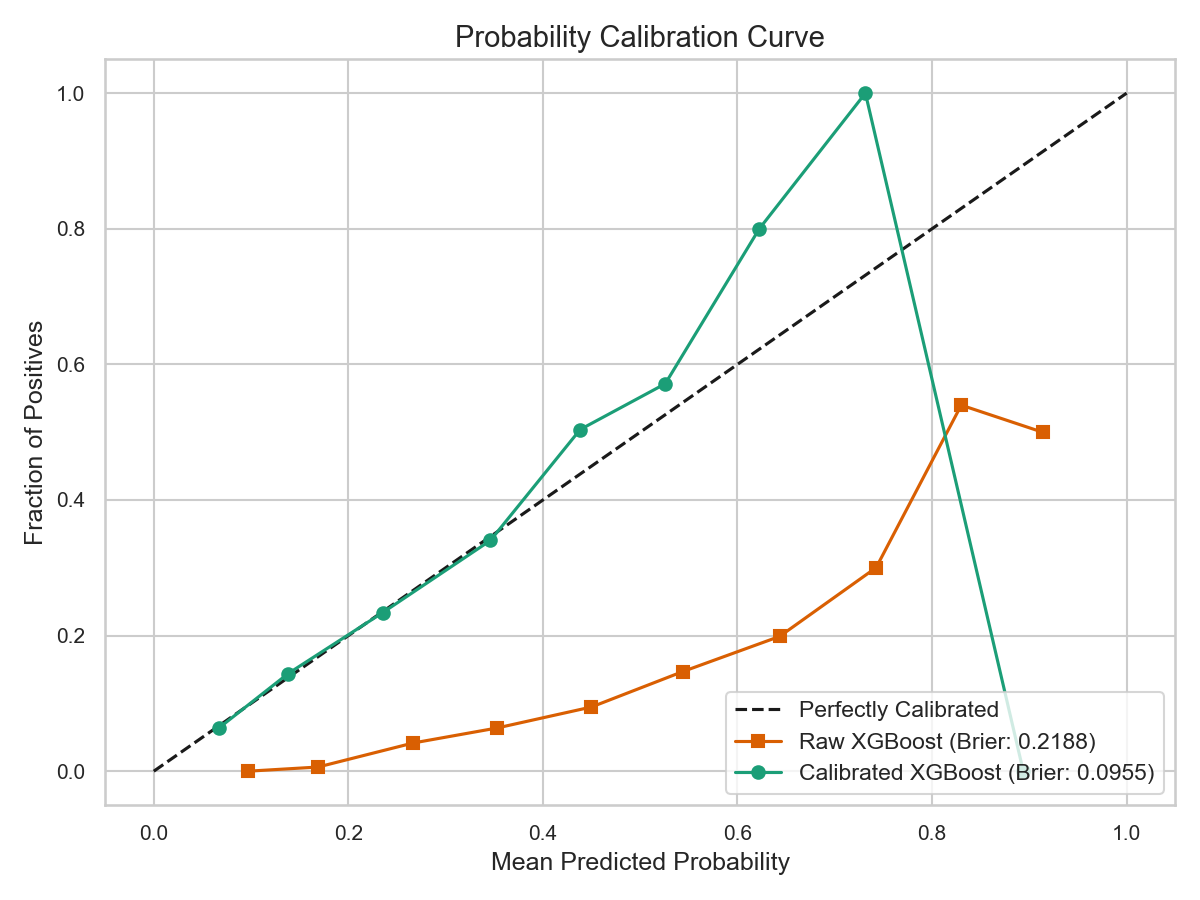

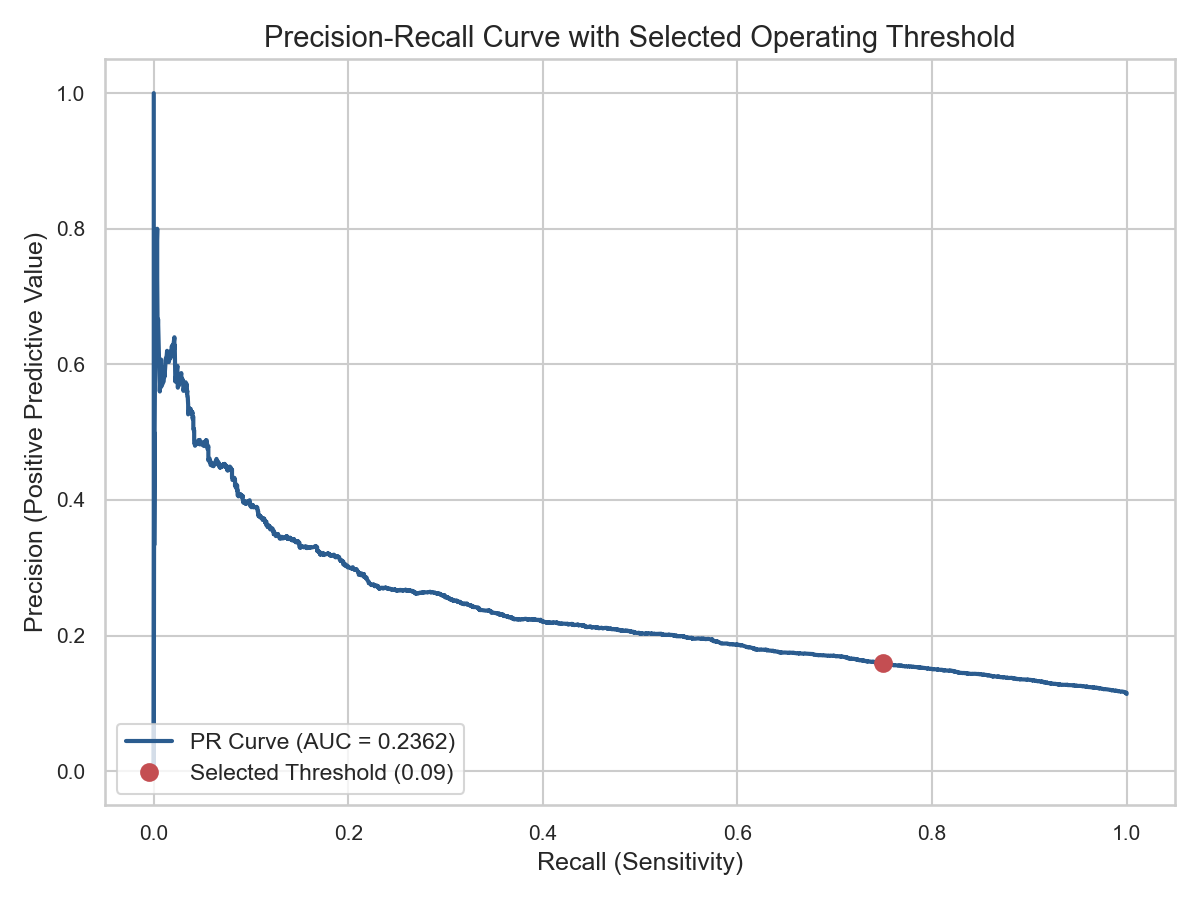

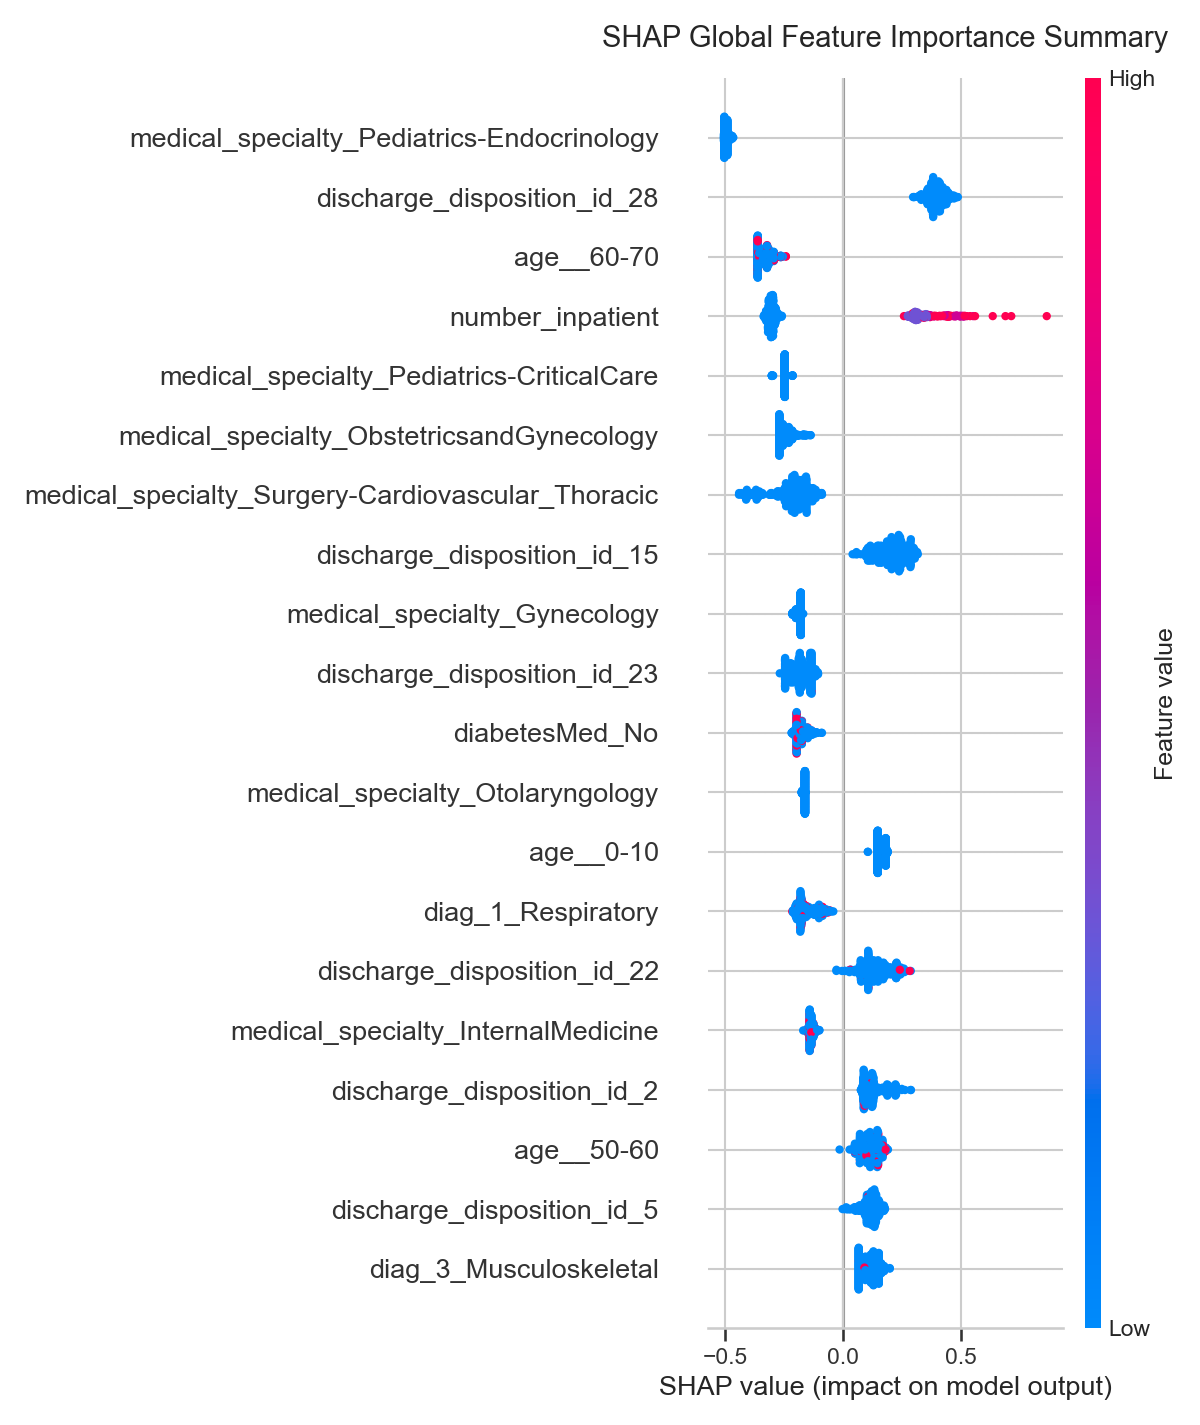

In [3]:
display(Image(filename=str(outputs_dir / 'calibration_curve.png')))
display(Image(filename=str(outputs_dir / 'precision_recall_curve.png')))
display(Image(filename=str(outputs_dir / 'shap_summary.png')))


In [2]:
outputs_dir = repo_root / 'outputs'
audit_df = pd.read_csv(outputs_dir / 'bias_audit.csv')
audit_df.head()


,Feature,Subgroup,Sample Size,Readmission Count,Readmission Rate,Selection Rate,Precision,Recall,False Positive Rate,AUC-ROC
0,race,Caucasian,14743,1714,0.116259,0.546632,0.161434,0.759043,0.518689,0.680853
1,race,Hispanic,410,32,0.078049,0.439024,0.150000,0.843750,0.404762,0.782986
2,race,AfricanAmerican,3809,419,0.110003,0.529273,0.151786,0.730310,0.504425,0.668508
3,race,?,475,48,0.101053,0.397895,0.142857,0.562500,0.379391,0.667886
4,race,Asian,128,20,0.156250,0.445312,0.298246,0.850000,0.370370,0.806944


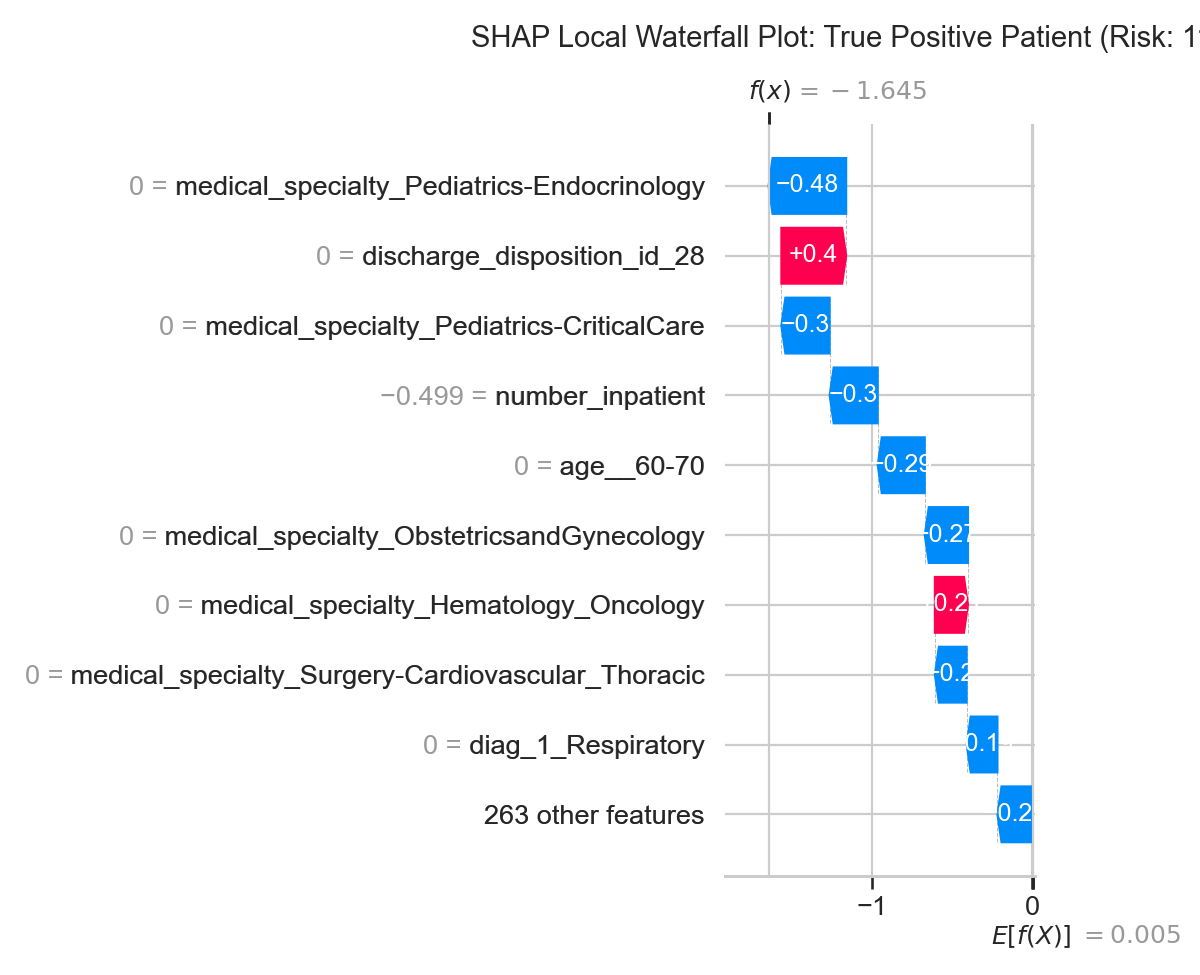

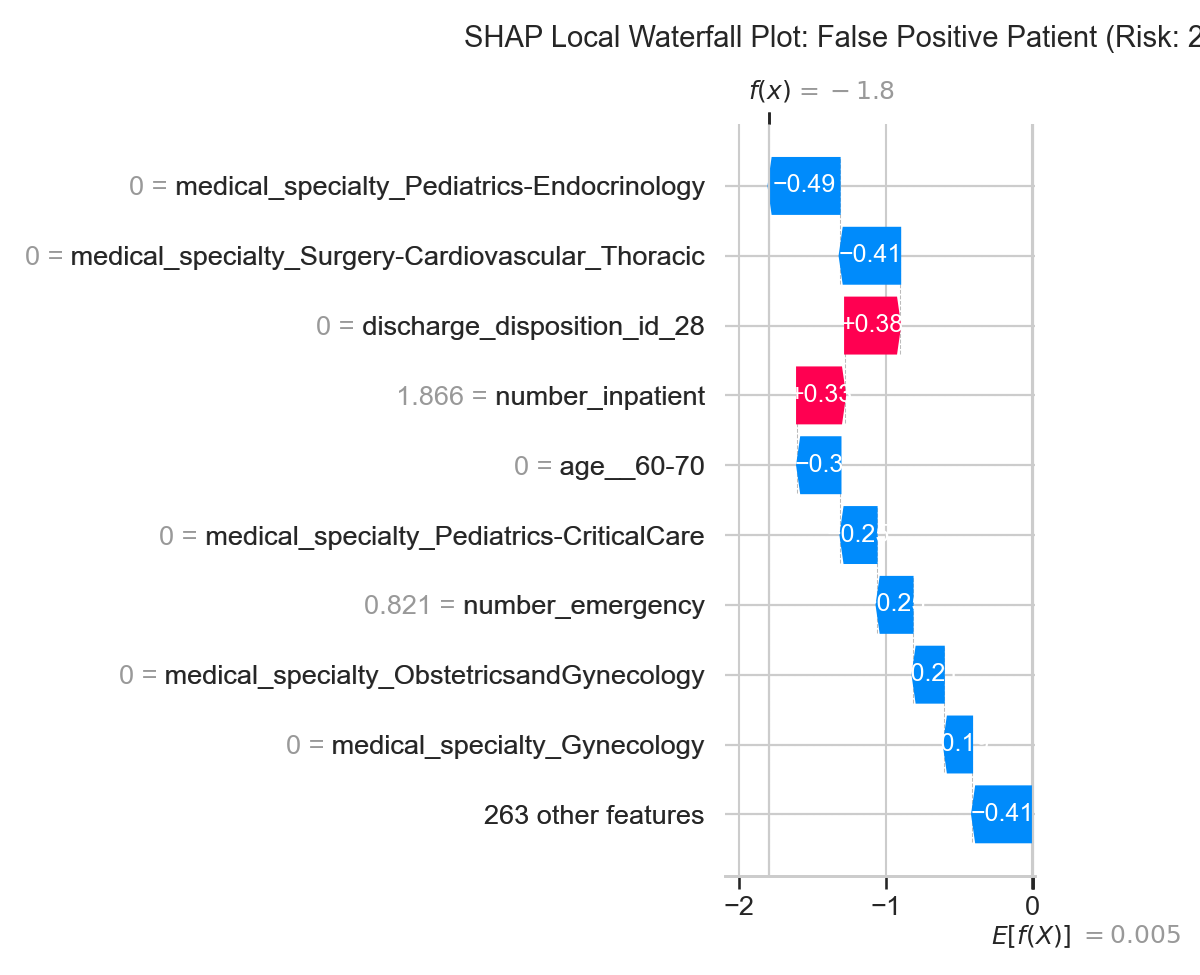

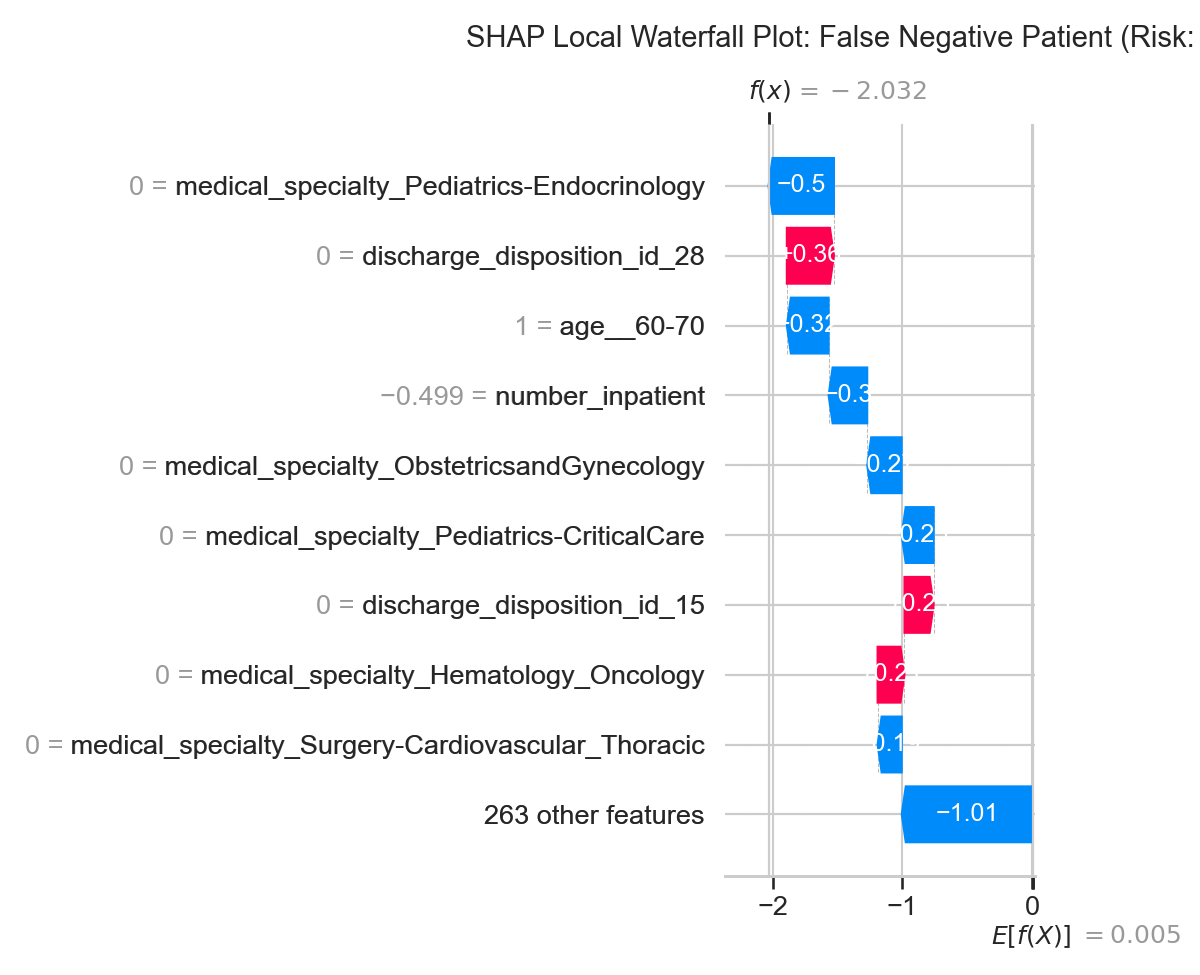

In [5]:
display(Image(filename=os.path.join(outputs_dir, 'shap_force_tp.png')))
display(Image(filename=os.path.join(outputs_dir, 'shap_force_fp.png')))
display(Image(filename=os.path.join(outputs_dir, 'shap_force_fn.png')))


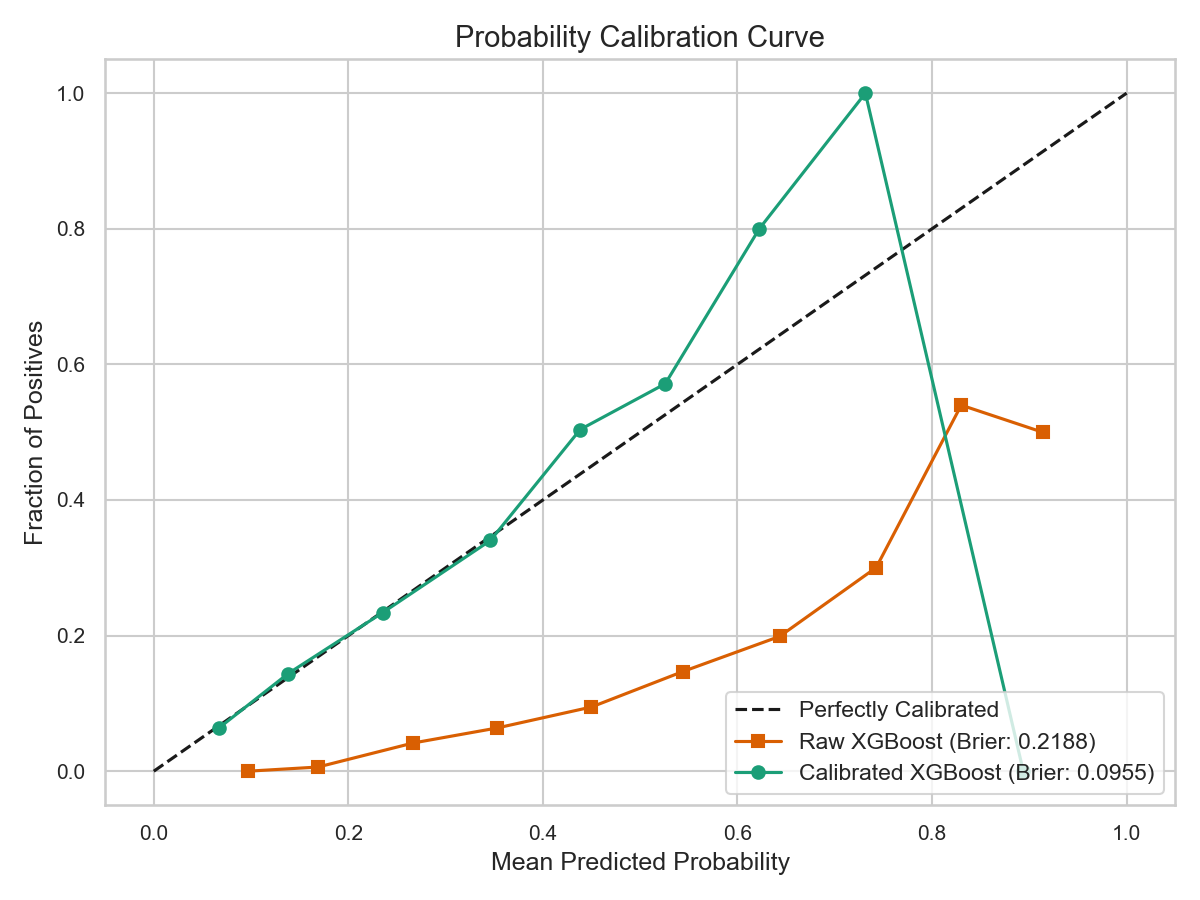

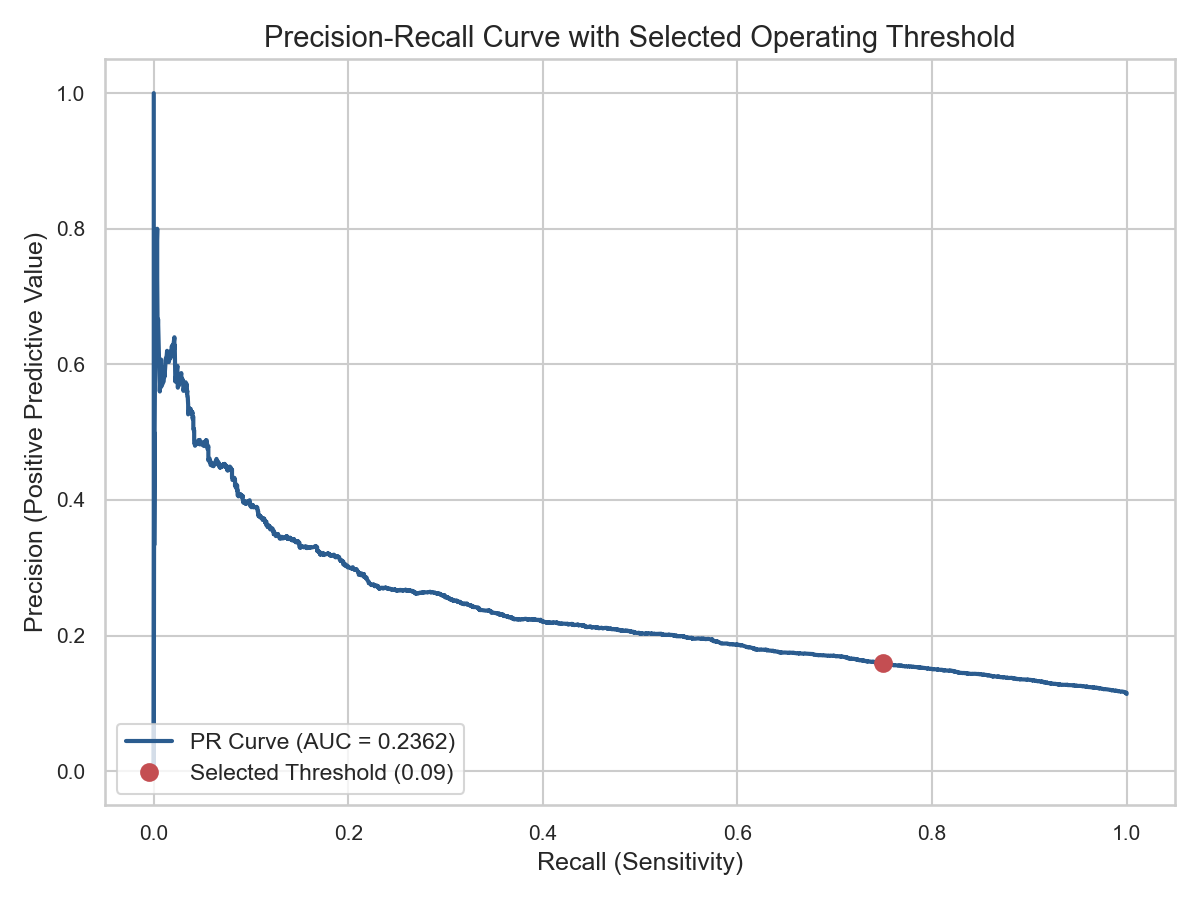

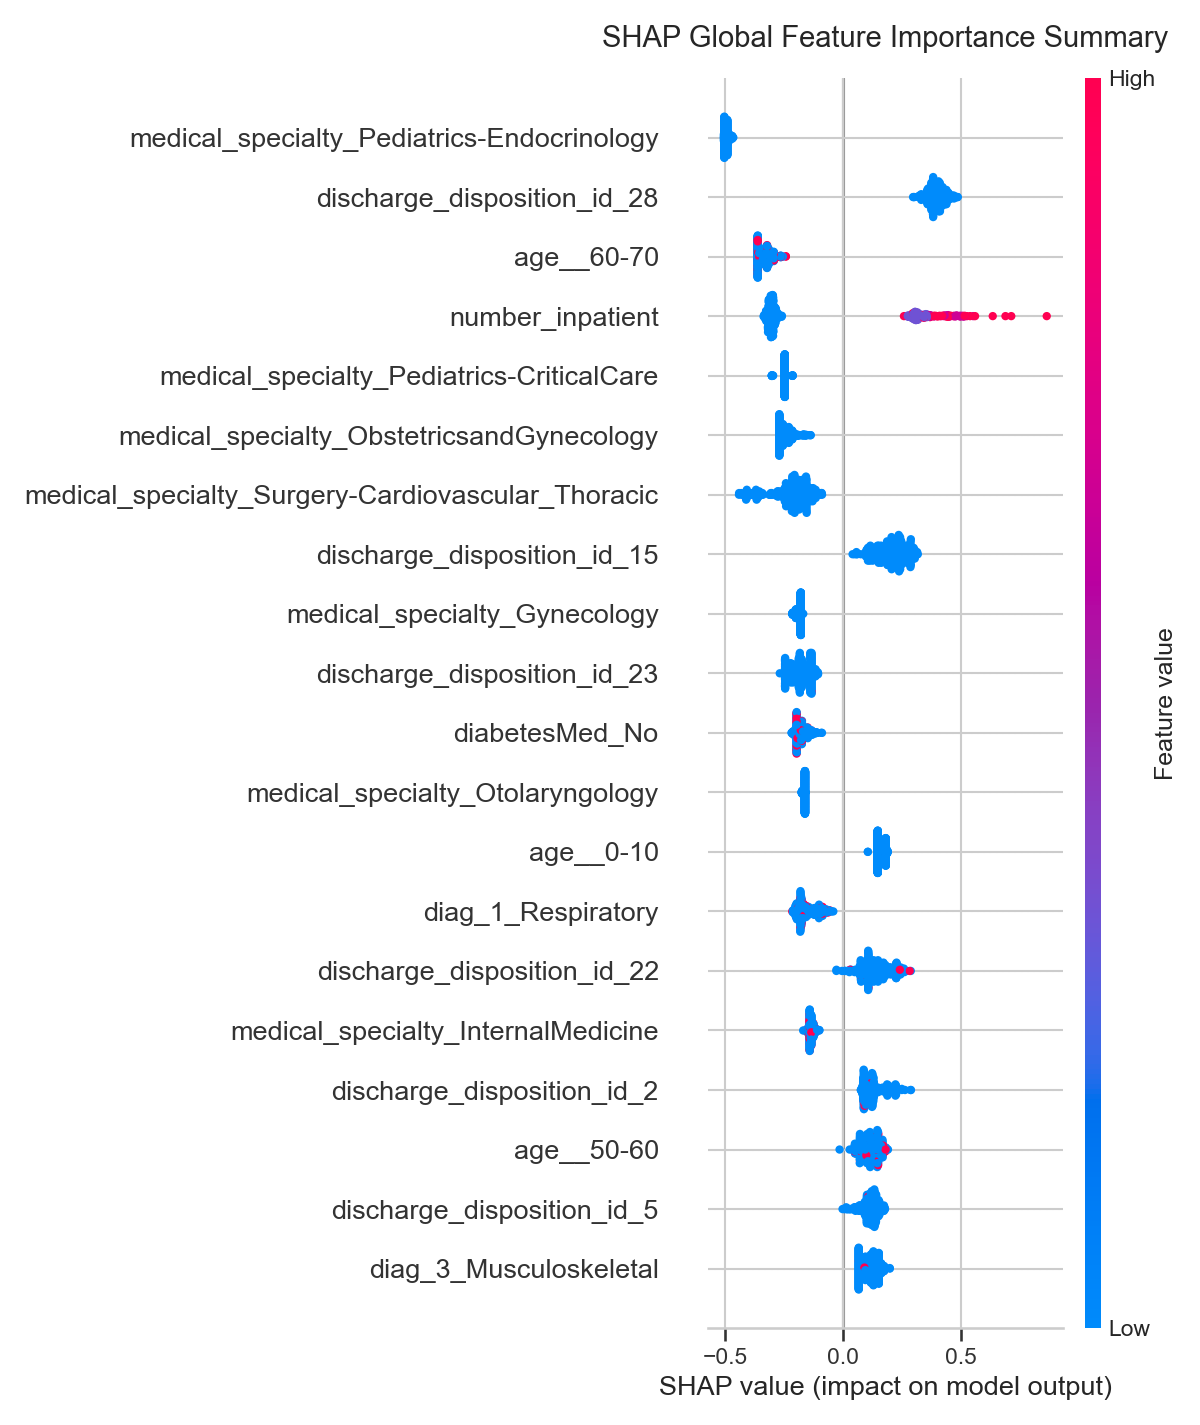

In [6]:
display(Image(filename=os.path.join(outputs_dir, 'calibration_curve.png')))
display(Image(filename=os.path.join(outputs_dir, 'precision_recall_curve.png')))
display(Image(filename=os.path.join(outputs_dir, 'shap_summary.png')))


In [8]:
outputs_dir = repo_root / 'outputs'
audit_df = pd.read_csv(outputs_dir / 'bias_audit.csv')
audit_df.head()


,Feature,Subgroup,Sample Size,Readmission Count,Readmission Rate,Selection Rate,Precision,Recall,False Positive Rate,AUC-ROC
0,race,Caucasian,14743,1714,0.116259,0.546632,0.161434,0.759043,0.518689,0.680853
1,race,Hispanic,410,32,0.078049,0.439024,0.150000,0.843750,0.404762,0.782986
2,race,AfricanAmerican,3809,419,0.110003,0.529273,0.151786,0.730310,0.504425,0.668508
3,race,?,475,48,0.101053,0.397895,0.142857,0.562500,0.379391,0.667886
4,race,Asian,128,20,0.156250,0.445312,0.298246,0.850000,0.370370,0.806944


## Generated Artifacts

The training run creates the serialized pipeline, calibration curve, precision-recall curve, SHAP summary plot, local SHAP explanations, and the subgroup bias audit table.
